In [2]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, recall_score, roc_auc_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from IPython.display import display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

#### Nesse notebook, geraremos um modelo simplificado, sem GridSearch, sem StratifiedKFold, apenas pra gerar nossa primeira pravisão e submissão, e avaliar o progresso do nosso modelo ao longo do percurso.

In [27]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X=X.copy()
        X['Total_vs_monthly'] = X['TotalCharges']/X['MonthlyCharges']
        
        return X

<Axes: xlabel='tenure', ylabel='Churn'>

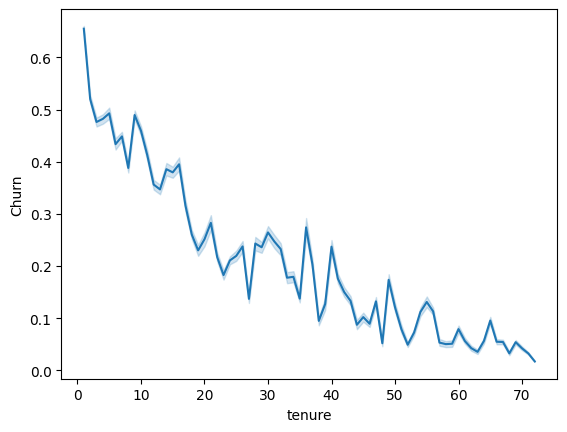

In [28]:
sns.lineplot(data=df, x='tenure', y='Churn')

In [29]:
df = joblib.load('df_att.pkl')

index = df['id']

target = 'Churn'

X = df.drop([target, 'id'], axis=1)
y = df[target]

In [30]:
def extract_xy(df):
    target = 'Churn'
    X = df.drop([target, 'id'], axis=1)
    y = df[target]
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

    return X_train, X_val, y_train, y_val



In [31]:
X_train, X_val, y_train, y_val = extract_xy(df)

cat_features = X_train.select_dtypes(exclude='number').columns.tolist()
num_features = X_train.select_dtypes(include='number').columns.tolist()

In [32]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Total_vs_monthly
39435,Female,0,Yes,Yes,62,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),24.60,1539.80,62.593496
326966,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.50,174.20,2.470922
279620,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Electronic check,80.45,80.45,1.000000
592468,Female,0,No,No,66,Yes,No,DSL,Yes,Yes,Yes,Yes,No,No,Two year,No,Bank transfer (automatic),66.75,3784.00,56.689139
100319,Female,0,Yes,Yes,62,Yes,Yes,DSL,No,Yes,No,Yes,Yes,Yes,Two year,No,Credit card (automatic),80.80,4862.50,60.179455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540364,Male,0,No,No,5,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.55,316.90,4.491850
450419,Female,0,Yes,Yes,64,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),20.70,1218.15,58.847826
487716,Female,0,Yes,Yes,38,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,717.50,36.421320
78231,Female,0,No,No,25,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.10,595.05,29.604478


In [42]:
model = CatBoostClassifier(iterations = 200, learning_rate=0.6, depth=6, l2_leaf_reg=1.2, border_count=150, eval_metric='AUC', cat_features=cat_features, verbose=100)

In [43]:
pipe = Pipeline([
    ('fe', FeatureEngineer()),
    ('model', model)
])

In [45]:
X_val = pipe.named_steps['fe'].transform(X_val)

pipe.fit(X_train, y_train, model__eval_set=(X_val, y_val))


0:	test: 0.8732067	best: 0.8732067 (0)	total: 630ms	remaining: 2m 5s
100:	test: 0.9139722	best: 0.9139763 (71)	total: 39.9s	remaining: 39.1s
199:	test: 0.9137573	best: 0.9139989 (120)	total: 1m 18s	remaining: 0us

bestTest = 0.9139989391
bestIteration = 120

Shrink model to first 121 iterations.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('fe', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False


In [46]:
pred = pipe.predict(X_val)

score = roc_auc_score(y_val, pred)
score

0.782224812272484

In [47]:
pipe.named_steps['model'].feature_importances_

array([ 0.14162092,  1.11942937,  0.27096249,  0.85745906, 14.97066541,
        0.73795036,  1.55366295,  0.63823107,  6.07559613,  0.47772341,
        0.47398902,  1.5778695 ,  0.45327793,  0.27071503, 17.99833593,
        9.03918539,  6.44954135, 16.49871118,  5.75038358, 14.64468993,
        0.        ])

In [48]:
pipe.fit(X, y)

0:	total: 416ms	remaining: 1m 22s
100:	total: 43.9s	remaining: 43.1s
199:	total: 1m 28s	remaining: 0us


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('fe', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False


In [49]:
test = joblib.load('test_att.pkl')
index = test['id']
test = test.drop('id', axis=1)

In [50]:


test_fe = pipe.named_steps['fe'].transform(test)

In [51]:
test_predict = model.predict_proba(test_fe)[:,1]
test_predict

array([0.0665885 , 0.00178258, 0.10699659, ..., 0.25698245, 0.00196651,
       0.39408003], shape=(254655,))

In [52]:
df_test = pd.DataFrame({'id': index, 'Churn': test_predict})

df_test.head(3)

,id,Churn
0,594194,0.066589
1,594195,0.001783
2,594196,0.106997


In [53]:
df_test.to_csv('1.3_submission.csv', index=False)


In [22]:
predict = pipe.predict(X_val)


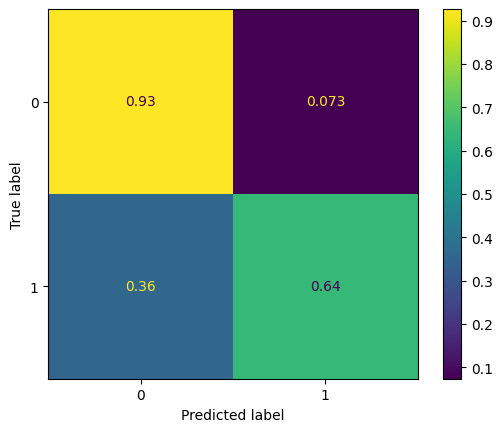

In [23]:
ConfusionMatrixDisplay.from_predictions(y_val, predict, normalize='true')

In [24]:
recall = recall_score(y_val, predict)

In [25]:
recall

0.643904277369512

In [34]:
df = pipe.named_steps['fe'].fit_transform(df)


In [35]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Total_vs_monthly
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0,27.518303
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0,54.362590
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0,58.180777
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1,1.014347
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1,1.000000


In [37]:
df.to_pickle('df_att.pkl')
